In [125]:
from avalanche.benchmarks.classic import SplitMNIST

benchmark = SplitMNIST(
    n_experiences=10,
    seed=1,
)

train_stream = benchmark.train_stream
test_stream = benchmark.test_stream

print(len(train_stream))
print(len(test_stream))

10
10


In [126]:
for exp in train_stream:
    print(
        f"Experience {exp.current_experience}: "
        f"classes={exp.classes_in_this_experience}, "
        f"length={len(exp.dataset)}"
    )

print("##########################")

for exp in test_stream:
    print(
        f"Experience {exp.current_experience}: "
        f"classes={exp.classes_in_this_experience}, "
        f"length={len(exp.dataset)}"
    )

Experience 0: classes=[5], length=5421
Experience 1: classes=[6], length=5918
Experience 2: classes=[1], length=6742
Experience 3: classes=[2], length=5958
Experience 4: classes=[0], length=5923
Experience 5: classes=[8], length=5851
Experience 6: classes=[9], length=5949
Experience 7: classes=[3], length=6131
Experience 8: classes=[7], length=6265
Experience 9: classes=[4], length=5842
##########################
Experience 0: classes=[5], length=892
Experience 1: classes=[6], length=958
Experience 2: classes=[1], length=1135
Experience 3: classes=[2], length=1032
Experience 4: classes=[0], length=980
Experience 5: classes=[8], length=974
Experience 6: classes=[9], length=1009
Experience 7: classes=[3], length=1010
Experience 8: classes=[7], length=1028
Experience 9: classes=[4], length=982


In [127]:
exp = train_stream[0]

print(exp.classes_in_this_experience)
print(len(exp.dataset))

[5]
5421


In [128]:
image, label, task_id = exp.dataset[0]

print("Label:", label)
print("Task:", task_id)
print("Shape:", image.shape)

Label: 5
Task: 0
Shape: torch.Size([1, 28, 28])


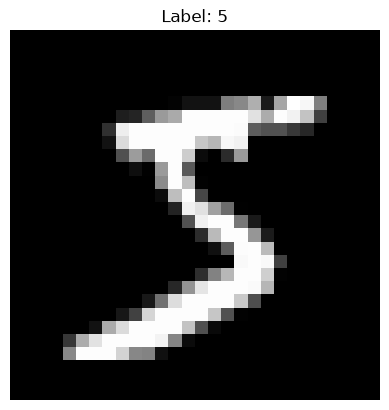

In [129]:
import matplotlib.pyplot as plt

plt.imshow(image.squeeze(), cmap="gray")
plt.title(f"Label: {label}")
plt.axis("off")
plt.show()

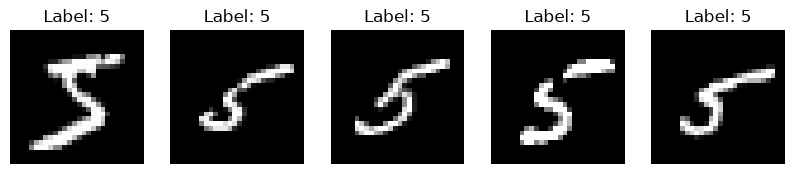

In [130]:
fig, axes = plt.subplots(1, 5, figsize=(10, 2))

for i in range(5):
    image, label, task_id = exp.dataset[i]

    axes[i].imshow(image.squeeze(), cmap="gray")
    axes[i].set_title(f"Label: {label}")
    axes[i].axis("off")

plt.show()

In [131]:
print(image.shape)

x = image.flatten()

print(x.shape)

torch.Size([1, 28, 28])
torch.Size([784])


In [132]:
import torch

model = torch.nn.Linear(784, 10)

print(model)

Linear(in_features=784, out_features=10, bias=True)


In [133]:
logits = model(x)

print("Label:", label)
print("Logits shape:", logits.shape)
print("Logits:", logits)

Label: 5
Logits shape: torch.Size([10])
Logits: tensor([ 0.1894, -0.3482,  0.1070,  0.2694,  0.3283, -1.3517,  0.1506,  0.2339,
         0.0022,  0.2323], grad_fn=<ViewBackward0>)


In [134]:
prediction = logits.argmax()

print(prediction)

tensor(4)


In [135]:
for i in range(5):
    image, label, task_id = exp.dataset[i]
    print(i, image.shape, label, task_id)

0 torch.Size([1, 28, 28]) 5 0
1 torch.Size([1, 28, 28]) 5 0
2 torch.Size([1, 28, 28]) 5 0
3 torch.Size([1, 28, 28]) 5 0
4 torch.Size([1, 28, 28]) 5 0


In [136]:
labels = [exp.dataset[i][1] for i in range(len(exp.dataset))]

print(set(labels))
print(len(labels))

{5}
5421


In [137]:
x = image.flatten()

print("x shape:", x.shape)
print("label:", label)
print("first 10 pixels:", x[:10])

x shape: torch.Size([784])
label: 5
first 10 pixels: tensor([-0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242,
        -0.4242, -0.4242])


In [138]:
print("Number of experiences:", len(train_stream))

for i, exp in enumerate(train_stream):
    labels = set(exp.dataset[i][1] for i in range(len(exp.dataset)))
    print(i, labels, len(exp.dataset))

Number of experiences: 10
0 {5} 5421
1 {6} 5918
2 {1} 6742
3 {2} 5958
4 {0} 5923
5 {8} 5851
6 {9} 5949
7 {3} 6131
8 {7} 6265
9 {4} 5842


In [139]:
x = image.flatten()

z = model(x)

print("x:", x.shape)
print("z:", z.shape)
print("label:", label)
print("Z:", z)
print("predicted", z.argmax())

x: torch.Size([784])
z: torch.Size([10])
label: 5
Z: tensor([ 0.1894, -0.3482,  0.1070,  0.2694,  0.3283, -1.3517,  0.1506,  0.2339,
         0.0022,  0.2323], grad_fn=<ViewBackward0>)
predicted tensor(4)


In [140]:
import torch.nn as nn

criterion = nn.CrossEntropyLoss()

loss = criterion(z.unsqueeze(0), torch.tensor([label]))

print("Loss:", loss.item())

Loss: 3.7194738388061523


In [141]:
prediction = z.argmax()

print("Prediction:", prediction.item())
print("True label:", label)

Prediction: 4
True label: 5


In [142]:
model.zero_grad()
loss.backward()

print(model.weight.grad.shape)
print(model.bias.grad.shape)

torch.Size([10, 784])
torch.Size([10])


In [143]:
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

# Update W and b
optimizer.step()

# Run the SAME image through the UPDATED model
z_new = model(x)

prediction_new = z_new.argmax()

print("Old prediction:", z.argmax().item())
print("New prediction:", prediction_new.item())
print("True label:", label)
print("New logits:", z_new)

Old prediction: 4
New prediction: 5
True label: 5
New logits: tensor([-0.4126, -0.6999, -0.4474, -0.3828, -0.3634,  3.8364, -0.4285, -0.3955,
        -0.4970, -0.3961], grad_fn=<ViewBackward0>)


In [144]:
images = []
labels = []

for i in range(32):
    image, label, task_id = exp.dataset[i]
    images.append(image)
    labels.append(label)

x_batch = torch.stack(images)
y_batch = torch.tensor(labels)

print("x_batch:", x_batch.shape)
print("y_batch:", y_batch.shape)

x_batch: torch.Size([32, 1, 28, 28])
y_batch: torch.Size([32])


In [145]:
x_batch_flat = x_batch.flatten(start_dim=1)
z_batch = model(x_batch_flat)

print("x_batch_flat:", x_batch_flat.shape)
print("z_batch:", z_batch.shape)

x_batch_flat: torch.Size([32, 784])
z_batch: torch.Size([32, 10])


In [146]:
predictions = z_batch.argmax(dim=1)

print(predictions.shape)
print(predictions)

torch.Size([32])
tensor([2, 5, 3, 5, 5, 1, 7, 5, 7, 5, 5, 9, 5, 5, 5, 5, 7, 5, 8, 5, 1, 5, 7, 3,
        5, 5, 1, 9, 5, 3, 3, 1])


In [147]:
print("Predictions:", predictions)
print("True labels:", y_batch)

Predictions: tensor([2, 5, 3, 5, 5, 1, 7, 5, 7, 5, 5, 9, 5, 5, 5, 5, 7, 5, 8, 5, 1, 5, 7, 3,
        5, 5, 1, 9, 5, 3, 3, 1])
True labels: tensor([4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
        4, 4, 4, 4, 4, 4, 4, 4])


In [148]:
loss = criterion(z_batch, y_batch)

print("Loss:", loss.item())

Loss: 2.7789382934570312


In [149]:
model.train()

optimizer.zero_grad()

z_batch = model(x_batch_flat)

loss_after = criterion(z_batch, y_batch)

loss_after.backward()

optimizer.step()

print("Loss before update:", loss_after.item())

Loss before update: 2.7789382934570312


In [150]:
z_batch_after = model(x_batch_flat)
predictions_after = z_batch_after.argmax(dim=1)

print(predictions_after)

tensor([4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
        4, 4, 4, 4, 4, 4, 4, 4])


In [151]:
z_batch_after = model(x_batch_flat)

loss_after = criterion(z_batch_after, y_batch)

print("Loss before update:", loss.item())
print("Loss after update:", loss_after.item())

Loss before update: 2.7789382934570312
Loss after update: 0.49113669991493225


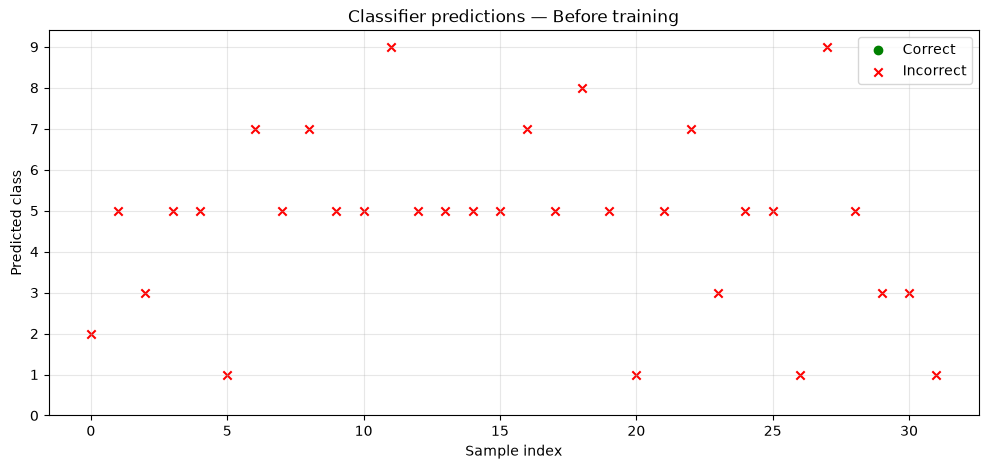

In [153]:
import matplotlib.pyplot as plt

indices = range(32)

# -----------------
# Before training
# -----------------
correct_before = predictions_before == y_batch
incorrect_before = ~correct_before

plt.figure(figsize=(12, 5))

plt.scatter(
    [i for i in indices if correct_before[i]],
    [predictions_before[i].item() for i in indices if correct_before[i]],
    marker="o",
    color="green",
    label="Correct"
)

plt.scatter(
    [i for i in indices if incorrect_before[i]],
    [predictions_before[i].item() for i in indices if incorrect_before[i]],
    marker="x",
    color="red",
    label="Incorrect"
)

plt.xlabel("Sample index")
plt.ylabel("Predicted class")
plt.yticks(range(10))
plt.title("Classifier predictions — Before training")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

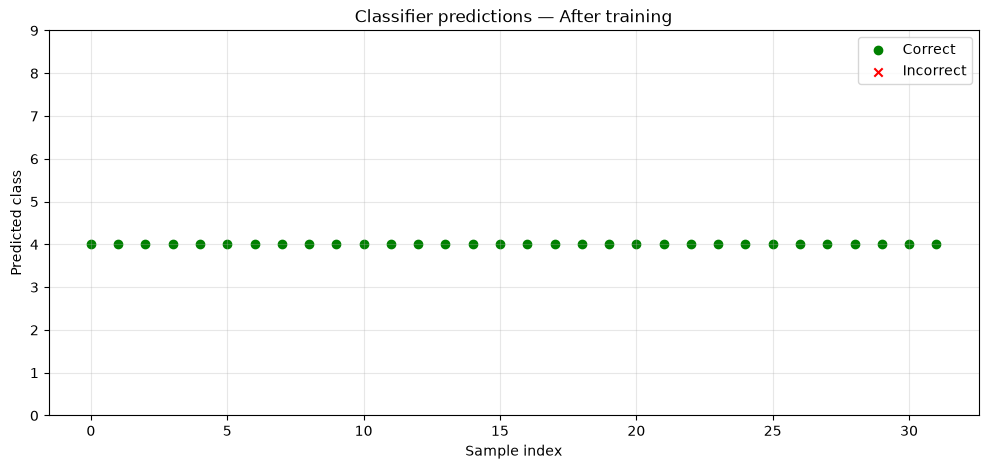

In [154]:
# -----------------
# After training
# -----------------
correct_after = predictions_after == y_batch
incorrect_after = ~correct_after

plt.figure(figsize=(12, 5))

plt.scatter(
    [i for i in indices if correct_after[i]],
    [predictions_after[i].item() for i in indices if correct_after[i]],
    marker="o",
    color="green",
    label="Correct"
)

plt.scatter(
    [i for i in indices if incorrect_after[i]],
    [predictions_after[i].item() for i in indices if incorrect_after[i]],
    marker="x",
    color="red",
    label="Incorrect"
)

plt.xlabel("Sample index")
plt.ylabel("Predicted class")
plt.yticks(range(10))
plt.title("Classifier predictions — After training")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [155]:
margins_before = (
    z_batch[:, 4]
    - z_batch[:, [0, 1, 2, 3, 5, 6, 7, 8, 9]].max(dim=1).values
)

margins_after = (
    z_batch_after[:, 4]
    - z_batch_after[:, [0, 1, 2, 3, 5, 6, 7, 8, 9]].max(dim=1).values
)

print(margins_before)
print(margins_after)

tensor([-0.7616, -1.1904, -1.8160, -0.4817, -1.7965, -1.8404, -2.1065, -2.8316,
        -0.4497, -0.8562, -1.1218, -0.6082, -1.2150, -1.9261, -1.3063, -0.6023,
        -1.3293, -2.2947, -1.4087, -0.9501, -1.6279, -0.8803, -1.7360, -1.5034,
        -1.0332, -1.0509, -0.9266, -1.0687, -0.9045, -1.3141, -1.2258, -0.6579],
       grad_fn=<SubBackward0>)
tensor([1.2580, 2.4966, 2.3148, 1.5867, 0.1733, 2.3182, 0.5742, 0.0521, 1.9084,
        2.7308, 1.6007, 2.8733, 2.0291, 2.1479, 2.7680, 2.4057, 1.5833, 1.4854,
        2.9054, 2.7945, 2.5195, 2.8884, 1.8630, 2.2770, 3.1997, 2.7745, 2.3115,
        2.7399, 2.8254, 1.6090, 2.5029, 2.9286], grad_fn=<SubBackward0>)


In [156]:
other_classes = [0, 1, 2, 3, 5, 6, 7, 8, 9]

margins_before = (
    z_batch[:, 4]
    - z_batch[:, other_classes].max(dim=1).values
)

print("Predictions:", predictions_before)
print("Margins:", margins_before)

Predictions: tensor([2, 5, 3, 5, 5, 1, 7, 5, 7, 5, 5, 9, 5, 5, 5, 5, 7, 5, 8, 5, 1, 5, 7, 3,
        5, 5, 1, 9, 5, 3, 3, 1])
Margins: tensor([-0.7616, -1.1904, -1.8160, -0.4817, -1.7965, -1.8404, -2.1065, -2.8316,
        -0.4497, -0.8562, -1.1218, -0.6082, -1.2150, -1.9261, -1.3063, -0.6023,
        -1.3293, -2.2947, -1.4087, -0.9501, -1.6279, -0.8803, -1.7360, -1.5034,
        -1.0332, -1.0509, -0.9266, -1.0687, -0.9045, -1.3141, -1.2258, -0.6579],
       grad_fn=<SubBackward0>)


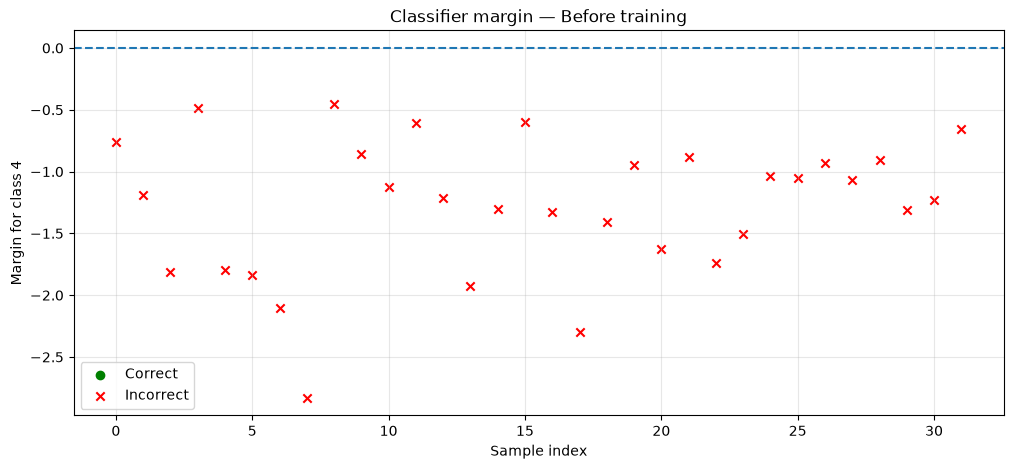

In [157]:
import matplotlib.pyplot as plt

correct = margins_before > 0
incorrect = margins_before <= 0

plt.figure(figsize=(12, 5))

plt.scatter(
    [i for i in range(32) if correct[i]],
    margins_before[correct].detach().numpy(),
    marker="o",
    color="green",
    label="Correct"
)

plt.scatter(
    [i for i in range(32) if incorrect[i]],
    margins_before[incorrect].detach().numpy(),
    marker="x",
    color="red",
    label="Incorrect"
)

plt.axhline(0, linestyle="--")

plt.xlabel("Sample index")
plt.ylabel("Margin for class 4")
plt.title("Classifier margin — Before training")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [158]:
margins_after = (
    z_batch_after[:, 4]
    - z_batch_after[:, other_classes].max(dim=1).values
)

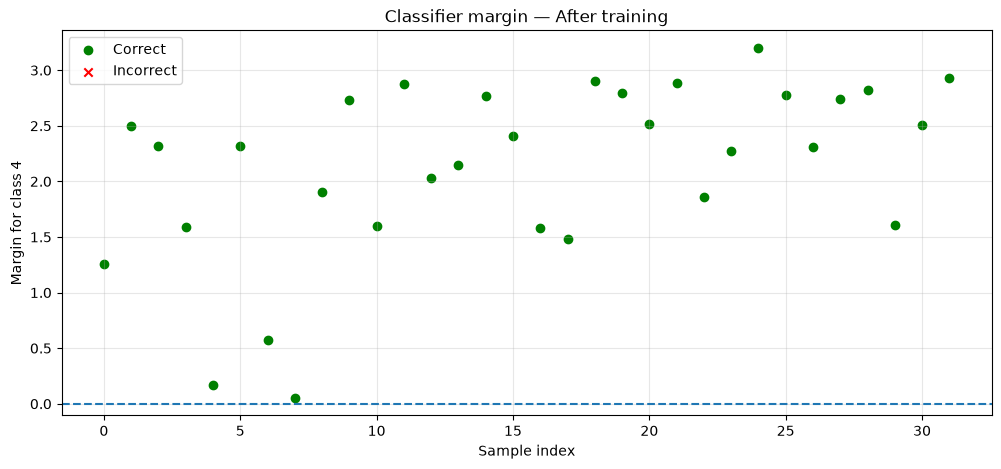

In [159]:
plt.figure(figsize=(12, 5))

correct = margins_after > 0
incorrect = margins_after <= 0

plt.scatter(
    [i for i in range(32) if correct[i]],
    margins_after[correct].detach().numpy(),
    marker="o",
    color="green",
    label="Correct"
)

plt.scatter(
    [i for i in range(32) if incorrect[i]],
    margins_after[incorrect].detach().numpy(),
    marker="x",
    color="red",
    label="Incorrect"
)

plt.axhline(0, linestyle="--")

plt.xlabel("Sample index")
plt.ylabel("Margin for class 4")
plt.title("Classifier margin — After training")
plt.legend()
plt.grid(alpha=0.3)
plt.show()